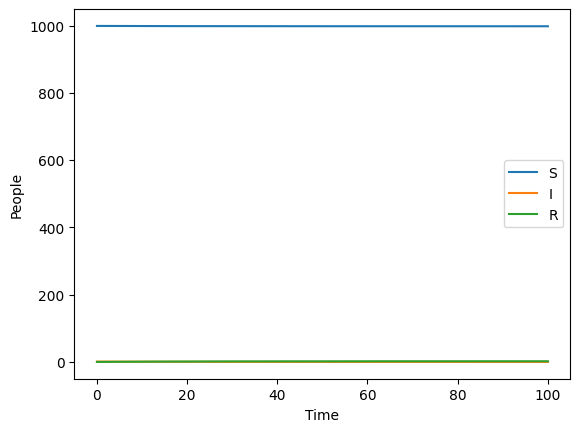

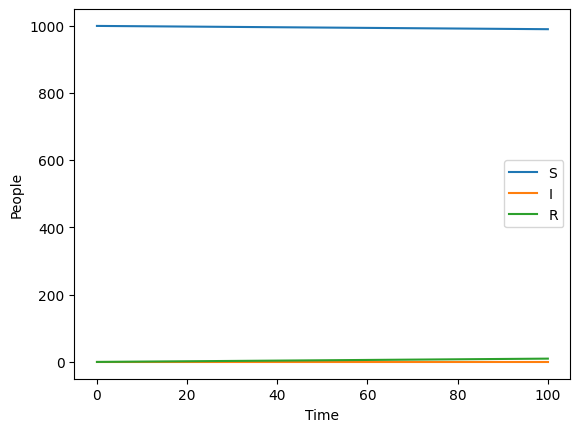

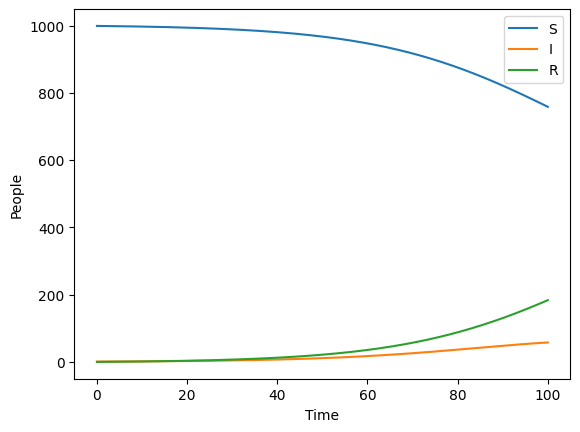

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


N = 1000

S0 = 999
I0 = 1
R0 = 0

t = np.linspace(0, 100, 500)

gamma = 0.1
beta_1 = 0.05
beta_2 = 0.10
beta_3 = 0.15


def sir(y, t, beta, gamma):
    S, I, R = y
    
    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I

    return [dS, dI, dR]


def plot_solution(solution):
    plt.plot(t, solution[:, 0], label="S")
    plt.plot(t, solution[:, 1], label="I")
    plt.plot(t, solution[:, 2], label="R")
    plt.xlabel("Time")
    plt.ylabel("People")
    plt.legend()
    plt.show()


solution_1 = odeint(sir, [S0, I0, R0], t,args=(beta_1, gamma))
solution_2 = odeint(sir, [S0, I0, R0], t, args=(beta_2, gamma))
solution_3 = odeint(sir, [S0, I0, R0], t, args=(beta_3, gamma))

plot_solution(solution_1)
plot_solution(solution_2)
plot_solution(solution_3)

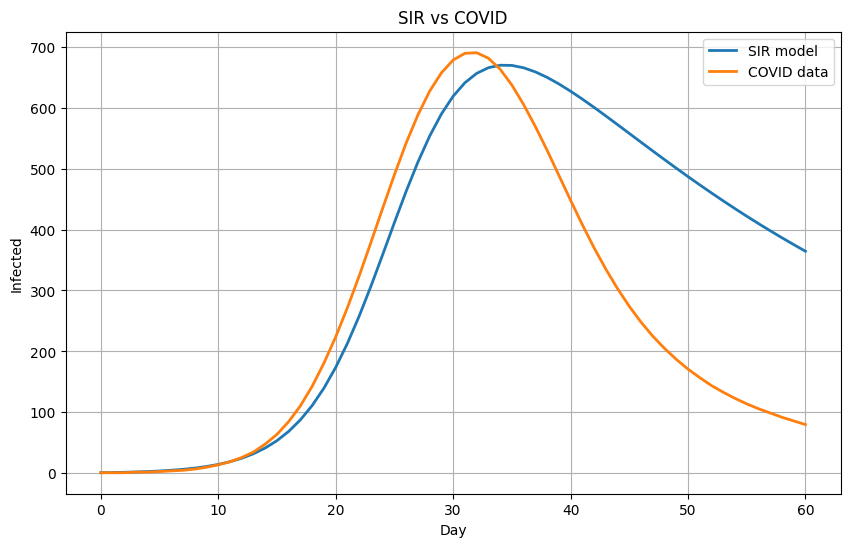

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint


N = 1000

S0 = 999
I0 = 1
R0 = 0

beta = 0.3
gamma = 0.03

data = pd.read_csv("datova_sada_covid.csv")

t = data["day"].values


def sir(y, t, beta, gamma):
    S, I, R = y

    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I

    return [dS, dI, dR]


solution = odeint(sir, [S0, I0, R0], t, args=(beta, gamma))

simulated_infected = solution[:, 1]
real_infected = data["infected"]

plt.figure(figsize=(10, 6))
plt.plot(t, simulated_infected, label="SIR model", linewidth=2)
plt.plot(t, real_infected, label="COVID data", linewidth=2)
plt.title("SIR vs COVID")
plt.xlabel("Day")
plt.ylabel("Infected")
plt.grid()
plt.legend()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
plt.show()

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


def sir(y, t, beta, gamma):
    S, I, R = y

    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I

    return [dS, dI, dR]


def sis(y, t, beta, gamma):
    S, I = y

    dS = -beta * S * I / N + gamma * I
    dI = beta * S * I / N - gamma * I

    return [dS, dI]


def sird(y, t, beta, gamma, mu):
    S, I, R, D = y

    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I - mu * I
    dR = gamma * I
    dD = mu * I

    return [dS, dI, dR, dD]


def sirvd(y, t, beta, gamma, mu, nu):
    S, I, R, V, D = y

    dS = -beta * S * I / N - nu * S
    dI = beta * S * I / N - gamma * I - mu * I
    dR = gamma * I
    dV = nu * S
    dD = mu * I

    return [dS, dI, dR, dV, dD]


def lotka_volterra(y, t, alpha, beta, delta, gamma):
    X, Y = y

    dX = alpha * X - beta * X * Y
    dY = delta * X * Y - gamma * Y

    return [dX, dY]